In [1]:
import pandas as pd

In [17]:
PATH = "/home/helder/Projects/crown/tcc-qamethod-snpg/data/data.csv"

In [28]:
# Abrir csv em um dataframe
df = pd.read_csv(PATH)
df

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding,x,y,z
0,treino,Jorge Ivan Hmeljevski,Modelo para Sistemas de Supervisão de Mercado ...,tese,Engenharia do Conhecimento,2021,Florianópolis,José Leomar Todesco,Alexandre Leopoldo Gonçalves,A confiança na higidez dos mercados de capitai...,"['Mercado de Capitais', 'Mercado de Valores Mo...",The confidence in the integrity of capital mar...,"['Capital market', 'Securities Market', 'Marke...",{'contextualizacao': 'O mercado de capitais é ...,O modelo elaborado nest a pesquisa envolveu a ...,"[0.02262425608932972, 0.06360490620136261, 0.0...",-0.174124,0.159395,-0.060768
1,treino,IVAM GALVÃO FILHO,FRACTUS: APLICATIVO PARA APRENDIZAGEM DE FRAÇÕES,dissertação,Engenharia do Conhecimento,2022,Florianópolis,Vania Ribas Ulbricht,Elisa Maria Pivetta,O objetivo principal desta pesquisa foi o dese...,"['Objetos de Aprendizagem.', 'Frações.', 'Apli...",The main objective of this research was the de...,"['Learning Objects.', 'Fractions.', 'App for L...",{'contextualizacao': 'O sistema educacional br...,O trabalho realizado pela organização TODOS PE...,"[-0.006245349999517202, 0.065089151263237, 0.0...",0.143998,0.263873,-0.055491
2,treino,MÁRCIO CRESCENCIO,MODELO DE UMA REDE COLABORATIVA SUPORTADA POR ...,tese,Engenharia do Conhecimento,2022,Florianópolis,Alexandre Augusto Biz,José Leomar Todesco,A convergência entre o turismo e a cultura atr...,"['Sítios de Patrimônio Mundial', 'Gestão do tu...",The convergence between tourism and culture th...,"['World Heritage Sites', 'Tourism management',...",{'contextualizacao': 'O turismo se tornou uma ...,Esta tese identificou que o turismo possui um ...,"[0.024945586919784546, 0.04501194879412651, 0....",-0.111669,-0.167909,-0.015695
3,treino,Roseli Honorio,MODELO CONCEITUAL DE GOVERNANÇA DE DADOS COMO ...,dissertação,Engenharia do Conhecimento,2022,Florianópolis,João Artur de Souza,Patrícia de Sá Freire,A humanidade passou por transformações e revol...,"['Governança de Dados', 'Governança do Conheci...",Humanity has undergone transformations and rev...,"['Data Governance', 'Knowledge Governance', 'F...",{'contextualizacao': 'A sociedade está atraves...,"Na Ind ústria 4.0 e Sociedade 5.0, as organiza...","[0.05032069981098175, 0.051356106996536255, 0....",-0.229669,0.045873,-0.059402
4,treino,José Tadeu Silva,Análise da contribuição da engenharia do conhe...,dissertação,Engenharia do Conhecimento,2022,Florianópolis,Fernando A. Ostuni Gauthier,Marcelo Macedo,A presente dissertação aborda as questões emer...,"['comércio eletrônico', 'modelo de análise', '...",The present dissertation addresses the emergin...,"['e-commerce', 'analysis model', 'knowledge en...",{'contextualizacao': 'De acordo com Lemos (200...,A partir do objetivo geral de analisar as cont...,"[-0.0012473083334043622, 0.044789645820856094,...",-0.195246,0.141014,0.098894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,treino,Rosani Cesário Pereira,Competências essenciais dos pregoeiros: um est...,dissertação,Gestão do Conhecimento,2023,Florianópolis,Édis Mafra Lapolli,Gertrudes A. Dandolini,O modelo de gestão que vem se consolidando na ...,"['competências', 'competências essenciais', 'p...",The management model that has been consolidati...,"['competencies', 'essential competencies', 'pu...","{'contextualizacao': 'A autora, Rosani Cesário...",A pesquisa conclui que as competências essenci...,"[0.03604484349489212, 0.046274762600660324, 0....",-0.049497,-0.208519,-0.222047
146,treino,Fabíola Provensi,Gestão do Conhecimento e Cultura de Segurança ...,dissertação,Gestão do Conhecimento,2023,Florianópolis,Eduardo Juan Soriano Sierra,Neri Dos Santos,"No âmbito deste estudo, no que tange à Cultura...","['gestão do conhecimento', 'cultura de seguran...","In the scope of this study, regarding Safety C...","['knowledge management', 'safety culture

### Tratamentos iniciais

In [13]:
# Cópia do dataframe para tratamento
# df_treatment = df.copy()

PATH = "/home/helder/Projects/crown/tcc-qamethod-snpg/notebooks/statistic/data_treatment.csv"
df_treatment = pd.read_csv(PATH)

In [30]:
# 1. Verificar valores ausentes e visualizar as colunas que contêm valores NaN
missing_values = df_treatment.isnull().sum()
print("Valores ausentes em cada coluna:\n", missing_values)

Valores ausentes em cada coluna:
 modalidade              0
autor                   0
titulo                  0
tipo                    0
area_de_concentracao    0
ano_de_publicacao       0
local                   0
orientador              0
coorientador            5
resumo                  0
palavras_chave          0
abstract                0
keywords                0
introducao              0
conclusao               0
embedding               0
x                       0
y                       0
z                       0
dtype: int64


In [31]:
# 2. Remover linhas duplicadas, se houver
df_treatment.drop_duplicates(inplace=True)

In [32]:
# 3. Tratar valores ausentes
text_columns = df_treatment.select_dtypes(include=['object']).columns
df_treatment[text_columns] = df_treatment[text_columns].fillna("Não disponível")

In [33]:
# 4. Padronizar colunas de texto: Remover espaços extras e converter para maiúsculas ou minúsculas
def clean_text(text):
    return text.strip().lower() if isinstance(text, str) else text

for col in text_columns:
    df_treatment[col] = df_treatment[col].apply(clean_text)

In [3]:
df_treatment

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding,x,y,z
0,treino,jorge ivan hmeljevski,modelo para sistemas de supervisão de mercado ...,tese,engenharia do conhecimento,2021,florianópolis,jose leomar todesco,alexandre leopoldo goncalves,a confiança na higidez dos mercados de capitai...,"['mercado de capitais', 'mercado de valores mo...",the confidence in the integrity of capital mar...,"['capital market', 'securities market', 'marke...",{'contextualizacao': 'o mercado de capitais é ...,o modelo elaborado nest a pesquisa envolveu a ...,"[0.02262425608932972, 0.06360490620136261, 0.0...",-0.174124,0.159395,-0.060768
1,treino,ivam galvão filho,fractus: aplicativo para aprendizagem de frações,dissertação,engenharia do conhecimento,2022,florianópolis,vania ribas ulbricht,elisa maria pivetta,o objetivo principal desta pesquisa foi o dese...,"['objetos de aprendizagem.', 'frações.', 'apli...",the main objective of this research was the de...,"['learning objects.', 'fractions.', 'app for l...",{'contextualizacao': 'o sistema educacional br...,o trabalho realizado pela organização todos pe...,"[-0.006245349999517202, 0.065089151263237, 0.0...",0.143998,0.263873,-0.055491
2,treino,márcio crescencio,modelo de uma rede colaborativa suportada por ...,tese,engenharia do conhecimento,2022,florianópolis,alexandre augusto biz,jose leomar todesco,a convergência entre o turismo e a cultura atr...,"['sítios de patrimônio mundial', 'gestão do tu...",the convergence between tourism and culture th...,"['world heritage sites', 'tourism management',...",{'contextualizacao': 'o turismo se tornou uma ...,esta tese identificou que o turismo possui um ...,"[0.024945586919784546, 0.04501194879412651, 0....",-0.111669,-0.167909,-0.015695
3,treino,roseli honorio,modelo conceitual de governança de dados como ...,dissertação,engenharia do conhecimento,2022,florianópolis,joao artur de souza,patricia de sa freire,a humanidade passou por transformações e revol...,"['governança de dados', 'governança do conheci...",humanity has undergone transformations and rev...,"['data governance', 'knowledge governance', 'f...",{'contextualizacao': 'a sociedade está atraves...,"na ind ústria 4.0 e sociedade 5.0, as organiza...","[0.05032069981098175, 0.051356106996536255, 0....",-0.229669,0.045873,-0.059402
4,treino,josé tadeu silva,análise da contribuição da engenharia do conhe...,dissertação,engenharia do conhecimento,2022,florianópolis,fernando alvaro ostuni gauthier,marcelo macedo,a presente dissertação aborda as questões emer...,"['comércio eletrônico', 'modelo de análise', '...",the present dissertation addresses the emergin...,"['e-commerce', 'analysis model', 'knowledge en...",{'contextualizacao': 'de acordo com lemos (200...,a partir do objetivo geral de analisar as cont...,"[-0.0012473083334043622, 0.044789645820856094,...",-0.195246,0.141014,0.098894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,treino,rosani cesário pereira,competências essenciais dos pregoeiros: um est...,dissertação,gestão do conhecimento,2023,florianópolis,edis mafra lapolli,gertrudes a. dandolini,o modelo de gestão que vem se consolidando na ...,"['competências', 'competências essenciais', 'p...",the management model that has been consolidati...,"['competencies', 'essential competencies', 'pu...","{'contextualizacao': 'a autora, rosani cesário...",a pesquisa conclui que as competências essenci...,"[0.03604484349489212, 0.046274762600660324, 0....",-0.049497,-0.208519,-0.222047
146,treino,fabíola provensi,gestão do conhecimento e cultura de segurança ...,dissertação,gestão do conhecimento,2023,florianópolis,eduardo juan soriano sierra,neri dos santos,"no âmbito deste estudo, no que tange à cultura...","['gestão do conhecimento', 'cultura de seguran...","in the scope of this study, regarding safety c...","['knowledge management', 'safety cul

In [4]:
from unidecode import unidecode

# Função para remover acentos
def remove_accents(text):
    return unidecode(text)

# Função para remover espaços extras entre os nomes
def remove_extra_spaces(text):
    return ' '.join(text.split())

In [66]:
# Aplicar a função na coluna 'orientador' e 'coorientador'
df_treatment['orientador'] = df_treatment['orientador'].apply(remove_accents)
df_treatment['coorientador'] = df_treatment['coorientador'].apply(remove_accents)

In [67]:
# Aplicar a função na coluna 'orientador' e 'coorientador'
df_treatment['orientador'] = df_treatment['orientador'].apply(remove_extra_spaces)
df_treatment['coorientador'] = df_treatment['coorientador'].apply(remove_extra_spaces)

In [14]:
unique_orientadores_sorted = sorted(df_treatment['orientador'].unique())
unique_orientadores_sorted

['aires jose rover',
 'alexandre augusto biz',
 'alexandre leopoldo goncalves',
 'andrea valeria steil',
 'araci hack catapan',
 'clarissa stefani teixeira',
 'cristiano jose castro de almeida cunha',
 'denilson sell',
 'edis mafra lapolli',
 'eduardo juan soriano sierra',
 'eduardo moreira da costa',
 'fernando alvaro ostuni gauthier',
 'fernando jose spanhol',
 'francisco antonio pereira fialho',
 'gertrudes aparecida dandolini',
 'gregorio varvakis',
 'joao artur de souza',
 'joao bosco da mota alves',
 'jose leomar todesco',
 'lia caetano bastos',
 'luciane maria fadel',
 'marcelo macedo',
 'marcio vieira de souza',
 'maria jose baldessar',
 'neri dos santos',
 'patricia de sa freire',
 'paulo mauricio selig',
 'richard perassi luiz de sousa',
 'roberto carlos dos santos pacheco',
 'rogerio cid bastos',
 'tarcisio vanzin',
 'vania ribas ulbricht']

In [36]:
unique_coorientadores_sorted = sorted(df_treatment['coorientador'].unique())
unique_coorientadores_sorted

['alexandre augusto biz',
 'alexandre leopoldo goncalves',
 'ana marta flores',
 'andrea valeria steil',
 'araci hack catapan',
 'clarissa stefani teixeira',
 'cristiano jose castro de almeida cunha',
 'denilson sell',
 'edis mafra lapoli',
 'eduardo de freitas rocha loures',
 'elisa maria pivetta',
 'fernando alvaro ostuni gauthier',
 'fernando jose spanhol',
 'francisco antonio pereira fialho',
 'geneia lucas dos santos',
 'gertrudes aparecida dandolini',
 'gregorio jean varvakis rados',
 'helio aisenberg ferenhof',
 'inara antunes vieira willerding',
 'joao artur de souza',
 'joao bosco da mota alves',
 'jose leomar todesco',
 'julio monteiro teixeira',
 'lia caetano bastos',
 'louise de lira roedel botelho',
 'luciane maria fadel',
 'marcelo macedo',
 'marcio vieira de souza',
 'maria collier de mendonca',
 'maria jose baldessar',
 'maria lucia correa neves',
 'monica ramos carneiro',
 'nao disponivel',
 'neri dos santos',
 'patricia de sa freire',
 'paulo mauricio selig',
 'richar

In [39]:
# Remove a coluna de modalidade
df_treatment.drop(columns=['modalidade'], inplace=True)
df_treatment

,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding,x,y,z
0,jorge ivan hmeljevski,modelo para sistemas de supervisão de mercado ...,tese,engenharia do conhecimento,2021,florianópolis,jose leomar todesco,alexandre leopoldo goncalves,a confiança na higidez dos mercados de capitai...,"['mercado de capitais', 'mercado de valores mo...",the confidence in the integrity of capital mar...,"['capital market', 'securities market', 'marke...",{'contextualizacao': 'o mercado de capitais é ...,o modelo elaborado nest a pesquisa envolveu a ...,"[0.02262425608932972, 0.06360490620136261, 0.0...",-0.174124,0.159395,-0.060768
1,ivam galvão filho,fractus: aplicativo para aprendizagem de frações,dissertação,engenharia do conhecimento,2022,florianópolis,vania ribas ulbricht,elisa maria pivetta,o objetivo principal desta pesquisa foi o dese...,"['objetos de aprendizagem.', 'frações.', 'apli...",the main objective of this research was the de...,"['learning objects.', 'fractions.', 'app for l...",{'contextualizacao': 'o sistema educacional br...,o trabalho realizado pela organização todos pe...,"[-0.006245349999517202, 0.065089151263237, 0.0...",0.143998,0.263873,-0.055491
2,márcio crescencio,modelo de uma rede colaborativa suportada por ...,tese,engenharia do conhecimento,2022,florianópolis,alexandre augusto biz,jose leomar todesco,a convergência entre o turismo e a cultura atr...,"['sítios de patrimônio mundial', 'gestão do tu...",the convergence between tourism and culture th...,"['world heritage sites', 'tourism management',...",{'contextualizacao': 'o turismo se tornou uma ...,esta tese identificou que o turismo possui um ...,"[0.024945586919784546, 0.04501194879412651, 0....",-0.111669,-0.167909,-0.015695
3,roseli honorio,modelo conceitual de governança de dados como ...,dissertação,engenharia do conhecimento,2022,florianópolis,joao artur de souza,patricia de sa freire,a humanidade passou por transformações e revol...,"['governança de dados', 'governança do conheci...",humanity has undergone transformations and rev...,"['data governance', 'knowledge governance', 'f...",{'contextualizacao': 'a sociedade está atraves...,"na ind ústria 4.0 e sociedade 5.0, as organiza...","[0.05032069981098175, 0.051356106996536255, 0....",-0.229669,0.045873,-0.059402
4,josé tadeu silva,análise da contribuição da engenharia do conhe...,dissertação,engenharia do conhecimento,2022,florianópolis,fernando alvaro ostuni gauthier,marcelo macedo,a presente dissertação aborda as questões emer...,"['comércio eletrônico', 'modelo de análise', '...",the present dissertation addresses the emergin...,"['e-commerce', 'analysis model', 'knowledge en...",{'contextualizacao': 'de acordo com lemos (200...,a partir do objetivo geral de analisar as cont...,"[-0.0012473083334043622, 0.044789645820856094,...",-0.195246,0.141014,0.098894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,rosani cesário pereira,competências essenciais dos pregoeiros: um est...,dissertação,gestão do conhecimento,2023,florianópolis,edis mafra lapolli,gertrudes aparecida dandolini,o modelo de gestão que vem se consolidando na ...,"['competências', 'competências essenciais', 'p...",the management model that has been consolidati...,"['competencies', 'essential competencies', 'pu...","{'contextualizacao': 'a autora, rosani cesário...",a pesquisa conclui que as competências essenci...,"[0.03604484349489212, 0.046274762600660324, 0....",-0.049497,-0.208519,-0.222047
146,fabíola provensi,gestão do conhecimento e cultura de segurança ...,dissertação,gestão do conhecimento,2023,florianópolis,eduardo juan soriano sierra,neri dos santos,"no âmbito deste estudo, no que tange à cultura...","['gestão do conhecimento', 'cultura de seguran...","in the scope of this study, regarding safety c...","['knowledge management', 'safety culture', 'oc...",{'contextualizacao': 'a saúde e segurança 

In [74]:
df_treatment.to_csv('data_treatment.csv', index=False)

## Análises

In [41]:
import matplotlib.pyplot as plt

### Distribuição de Publicações por Ano

Contexto: Ver como as publicações estão distribuídas ao longo dos anos pode ajudar a identificar tendências e picos de interesse em determinadas áreas.

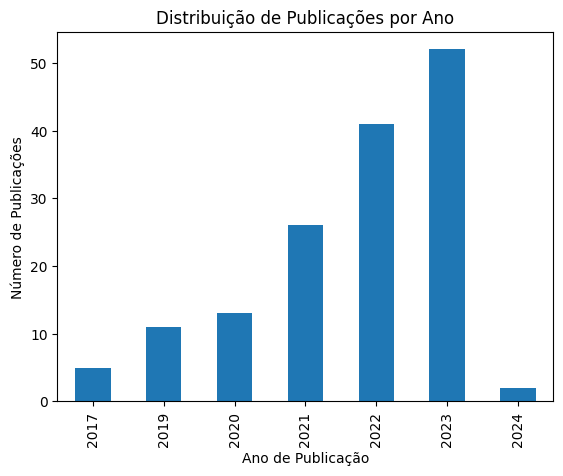

In [42]:
import matplotlib.pyplot as plt

df_treatment['ano_de_publicacao'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Distribuição de Publicações por Ano')
plt.show()


### Proporção de Tipos de Documentos (Tese vs. Dissertação)

Contexto: Analisar a proporção entre teses e dissertações ajuda a entender o foco do programa ou área de estudo.

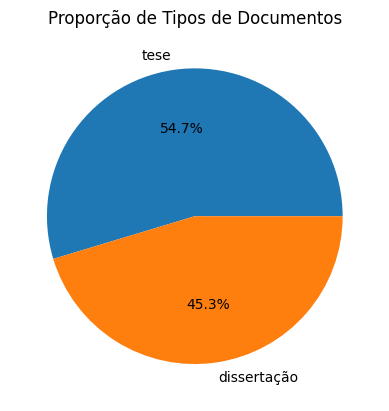

In [43]:
df_treatment['tipo'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporção de Tipos de Documentos')
plt.ylabel('')
plt.show()


### Principais Áreas de Concentração por Ano

Contexto: Visualizar as áreas de concentração mais comuns pode orientar futuros pesquisadores sobre temas populares e em desenvolvimento.

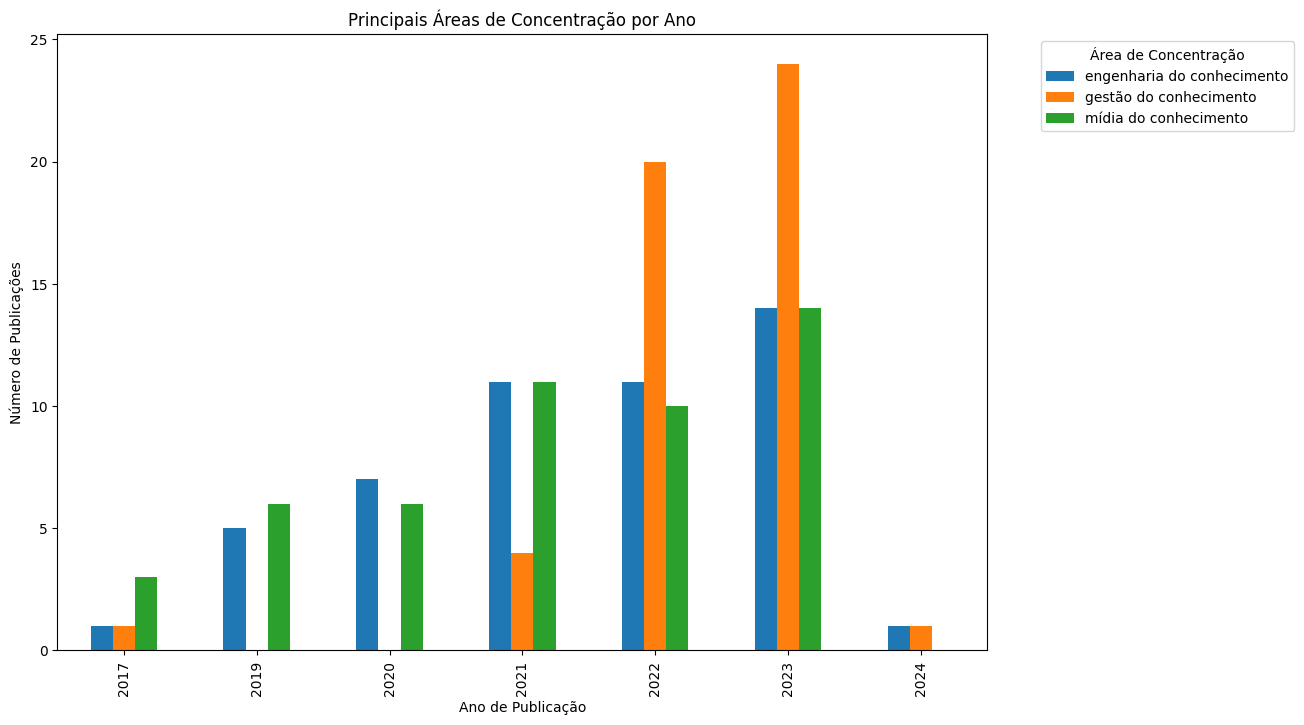

In [55]:
# Agrupar por ano e área de concentração, e contar o número de publicações
area_per_year = df_treatment.groupby(['ano_de_publicacao', 'area_de_concentracao']).size().unstack().fillna(0)

# Plotar as principais áreas de concentração por ano
area_per_year.plot(kind='bar', stacked=False, figsize=(12, 8))
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Principais Áreas de Concentração por Ano')
plt.legend(title='Área de Concentração', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Análise Temporal de Áreas de Concentração

Contexto: Examinar a evolução das áreas de concentração ao longo dos anos ajuda a entender o desenvolvimento das áreas de pesquisa.


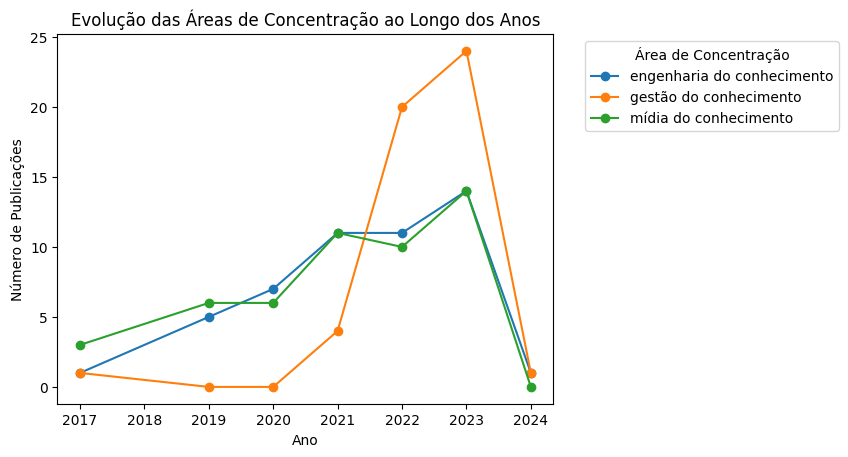

In [57]:
pivot_table = df_treatment.pivot_table(index='ano_de_publicacao', columns='area_de_concentracao', aggfunc='size', fill_value=0)
pivot_table.plot(kind='line', marker='o')
plt.xlabel('Ano')
plt.ylabel('Número de Publicações')
plt.title('Evolução das Áreas de Concentração ao Longo dos Anos')
plt.legend(title='Área de Concentração', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Mapa de Dispersão 3D das Coordenadas (x, y, z)

Contexto: Usar as coordenadas x, y e z para entender a distribuição espacial dos embeddings das publicações.

/tmp/ipykernel_291561/1878603113.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_areas))


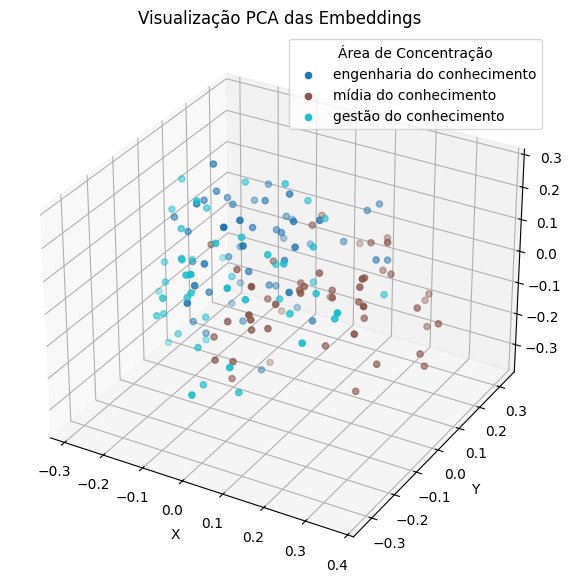

In [51]:
# Plotar as dimensões em um gráfico 3D com cores baseadas na área de concentração
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Definir um dicionário de cores para as áreas de concentração
unique_areas = df_treatment['area_de_concentracao'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_areas))
color_map = {area: colors(i) for i, area in enumerate(unique_areas)}

# Plotar os pontos com cores baseadas na área de concentração
for area in unique_areas:
    subset = df_treatment[df_treatment['area_de_concentracao'] == area]
    ax.scatter(subset['x'], subset['y'], subset['z'], label=area, color=color_map[area])

# Adicionar labels e título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Visualização PCA das Embeddings')

# Adicionar a legenda
ax.legend(title="Área de Concentração")

plt.show()

### Palavras-chave Mais Comuns

Contexto: Analisar as palavras-chave mais usadas indica os temas mais discutidos e permite explorar áreas emergentes.

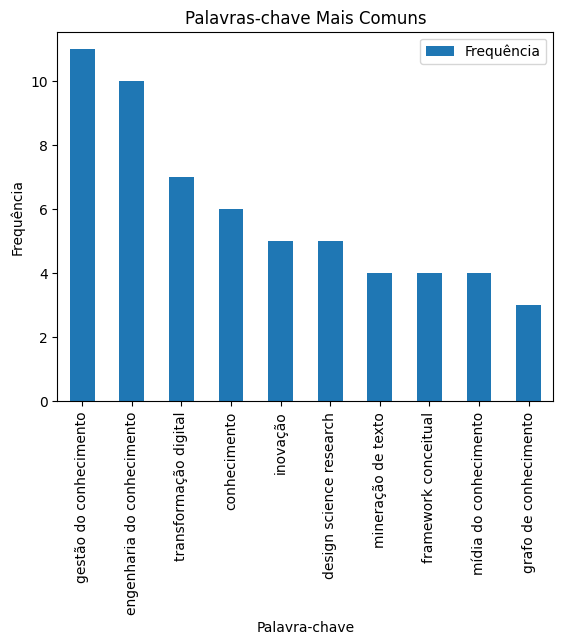

In [56]:
from collections import Counter
import ast

keywords = df_treatment['palavras_chave'].apply(ast.literal_eval).sum()
keywords_counter = Counter(keywords).most_common(10)
pd.DataFrame(keywords_counter, columns=['Palavra-chave', 'Frequência']).set_index('Palavra-chave').plot(kind='bar')
plt.ylabel('Frequência')
plt.title('Palavras-chave Mais Comuns')
plt.show()


### Análise de Orientadores Mais Frequentes

Contexto: Identificar orientadores frequentes revela líderes acadêmicos e suas contribuições para a formação de novos pesquisadores.

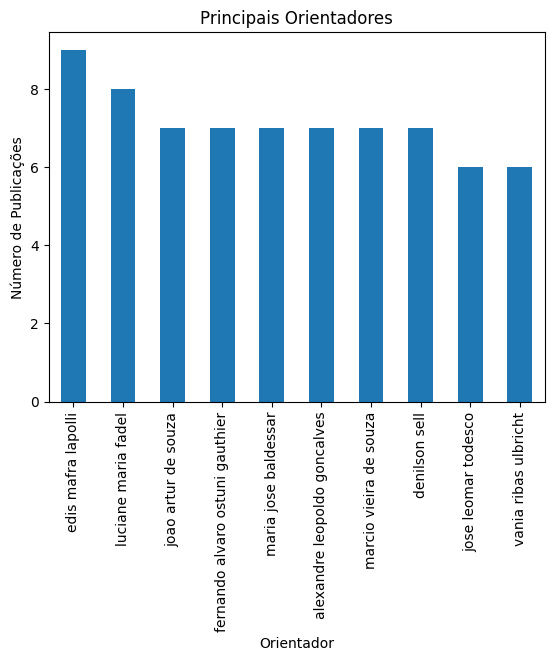

In [59]:
df_treatment['orientador'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Orientador')
plt.ylabel('Número de Publicações')
plt.title('Principais Orientadores')
plt.show()


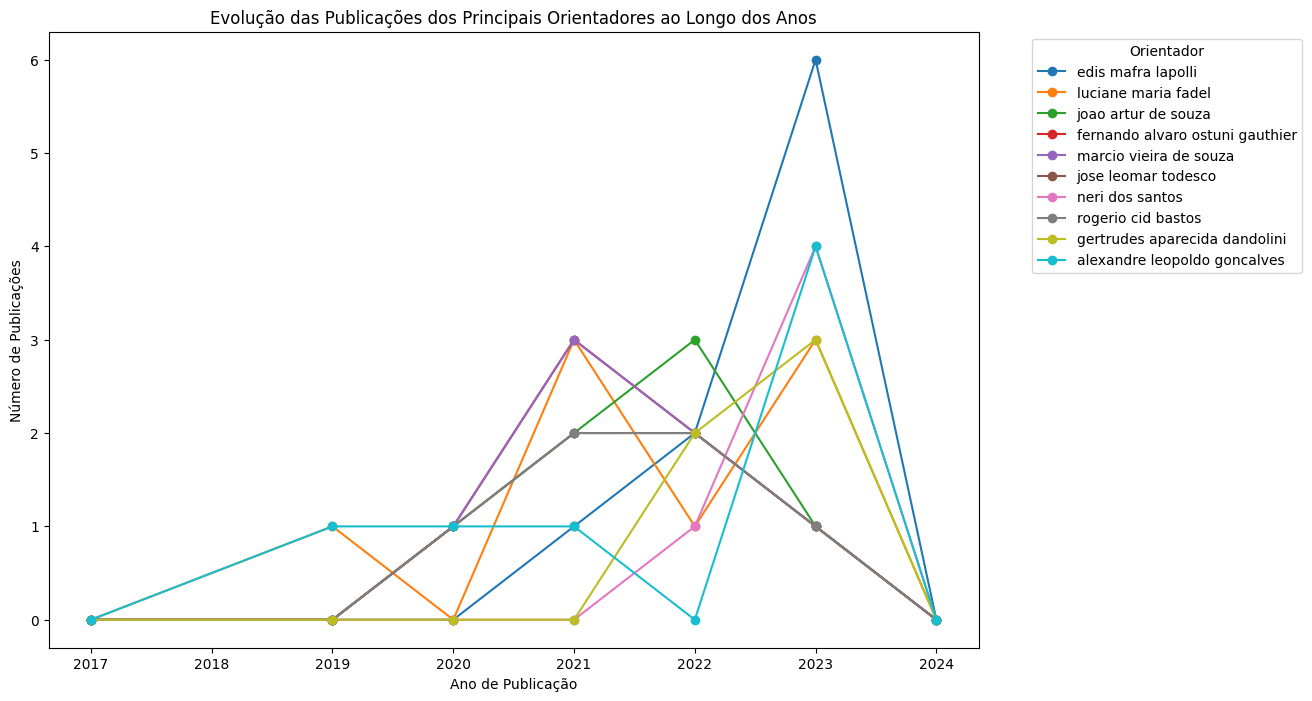

In [62]:
# Filtrar os orientadores mais frequentes
top_orientadores = orientadores_frequentes.head(10).index

# Filtrar os dados para os orientadores mais frequentes
orientadores_top_per_year = orientadores_per_year[top_orientadores]

# Plotar a evolução das publicações dos orientadores mais frequentes ao longo dos anos
orientadores_top_per_year.plot(kind='line', figsize=(12, 8), marker='o')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Evolução das Publicações dos Principais Orientadores ao Longo dos Anos')
plt.legend(title='Orientador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [73]:
# Encontrando os 10 orientadores que mais contribuíram em termos de publicações
top_orientadores = df_treatment['orientador'].value_counts().nlargest(10).index

# Filtrando o dataset original para conter apenas esses 10 principais orientadores
filtered_data = df_treatment[df_treatment['orientador'].isin(top_orientadores)]

# Agrupando os dados filtrados por ano, orientador e área de concentração e contando o número de publicações
orientadores_area_per_year = filtered_data.groupby(['orientador', 'ano_de_publicacao', 'area_de_concentracao']).size().unstack().fillna(0)

# Exibindo a tabela resultante
orientadores_area_per_year

area_de_concentracao                               engenharia do conhecimento  \
orientador                      ano_de_publicacao                               
alexandre leopoldo goncalves    2019                                      1.0   
                                2020                                      1.0   
                                2021                                      1.0   
                                2023                                      4.0   
denilson sell                   2017                                      0.0   
                                2019                                      2.0   
                                2022                                      1.0   
                                2023                                      1.0   
edis mafra lapolli              2021                                      0.0   
                                2022                                      0.0   
                                2023                                      0.0   
fernando alvaro ostuni gauthier 2020                                      1.0   
                                2021                                      3.0   
                                2022                                      2.0   
                                2023                                      1.0   
joao artur de souza             2020                                      0.0   
                                2021                                      1.0   
                                2022                                      3.0   
                                2023                                      1.0   
jose leomar todesco             2020                                      1.0   
                                2021                                      2.0   
                                2022                                      1.0   
                                2023                                      1.0   
luciane maria fadel             2019                                      0.0   
                                2021                                      0.0   
                                2022                                      0.0   
                                2023                                      0.0   
marcio vieira de souza          2020                                      0.0   
                                2021                                      0.0   
                                2022                                      0.0   
                                2023                                      0.0   
maria jose baldessar            2019                                      0.0   
                                2020                                      0.0   
                                2021                                      0.0   
                                2022                                      0.0   
vania ribas ulbricht            2019                                      0.0   
                                2021                                      0.0   
                                2022                                      1.0   
                                2023                                      0.0   

area_de_concentracao                               gestão do conhecimento  \
orientador                      ano_de_publicacao                           
alexandre leopoldo goncalves    2019                                  0.0   
                                2020                                  0.0   
                                2021                                  0.0   
                                2023                                  0.0   
denilson sell                   2017                                  1.0   
                                2019                                  0.0   
                                2022                          